# 02. Граф скелета

| вход | выход |
|---|---|
| файл чертежа и маска текста из этапа 01 | маска штрихов `strokes_mask` в рабочем масштабе |

Масштаб задается здесь и дальше не меняется: все пиксельные пороги следующих этапов измеряются в
пикселях этого кадра. Увеличение идет бикубикой, она восстанавливает по серой кайме вокруг штриха
плавный градиент, и толщины перестают слипаться при квантовании distance transform.

Граф строится, чтобы посмотреть на связность: отношение числа шпор к числу ребер узел-узел
показывает, насколько разорван контур. Сам граф в кеш не кладется, следующий этап собирает его
заново из маски.

In [3]:
from pathlib import Path

from artifact_cache import ArtifactCache
from ipywidgets import Dropdown, interactive
from stage_metrics import GraphMetrics, measure_graph_metrics, measure_mask_metrics
from visualization import build_view_window, draw_branch_types, show_mask, window_sliders

from draftslice.common_types import Mask, Mat
from draftslice.image_preparation import binarize_strokes, load_bgr_image, scale_image, scale_mask
from draftslice.stroke_graph import StrokeGraph, build_stroke_graph

DATASET_FOLDER = Path("../data")
WORKING_SCALE = 2.0

## Выбор файла

В списке только те файлы, для которых этап 01 уже посчитан.

In [4]:
cache = ArtifactCache()
source_files: list[Path] = [
    path for path in sorted(DATASET_FOLDER.glob("*.jpg")) if cache.has_stage(path, "text_region")
]
print(f"файлов с посчитанной маской текста: {len(source_files)}")


def run_source(file_index: int) -> Path:
    """Выбор файла среди посчитанных на этапе 01."""
    source_path = source_files[file_index]
    stored = cache.load_latest(source_path, "text_region")
    print(f"артефакт: {stored.path.name}")
    print(f"параметры этапа 01: {stored.parameters}")
    return source_path


ui_source = interactive(
    run_source,
    file_index=Dropdown(
        options=[(f"[{index}] {path.stem}", index) for index, path in enumerate(source_files)],
        value=0,
        description="файл",
    ),
)
ui_source

файлов с посчитанной маской текста: 1


interactive(children=(Dropdown(description='файл', options=(('[0] 21', 0),), value=0), Output()), _dom_classes…

## Масштаб и бинаризация

кадр 18478x11572 | порог Otsu 134
чернил 3.46% | кусков 616 | пустот 386
текстовая область 18.85% кадра


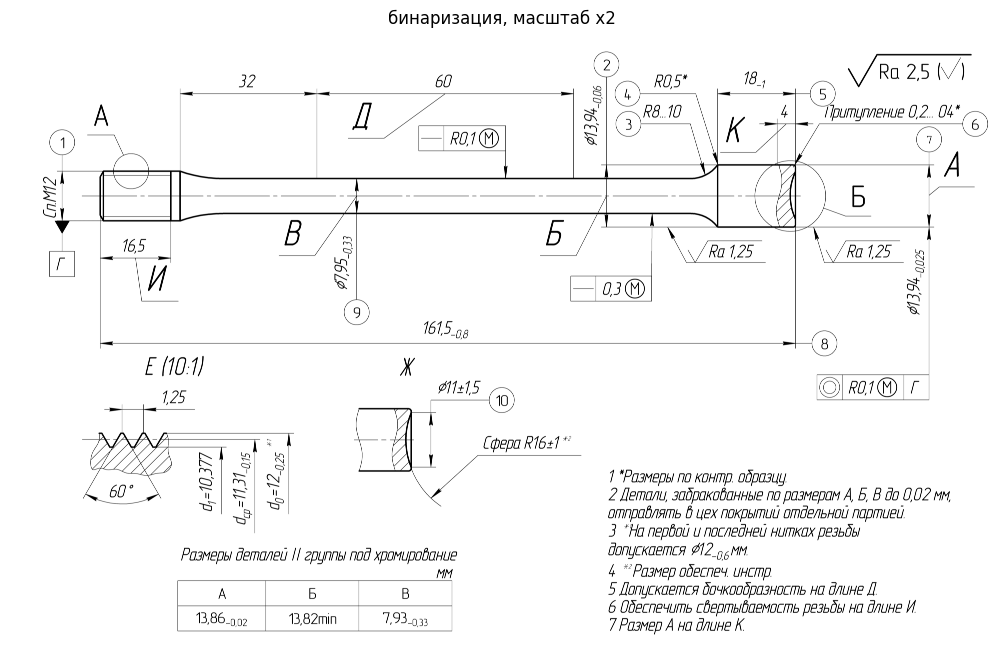

In [5]:
source_path: Path = ui_source.result
image: Mat = load_bgr_image(source_path)
text_region_mask: Mask = cache.load_latest(source_path, "text_region").arrays["text_region_mask"]

scaled_image: Mat = scale_image(image, WORKING_SCALE)
scaled_text_region: Mask = scale_mask(text_region_mask, WORKING_SCALE)
strokes = binarize_strokes(scaled_image)

mask_metrics = measure_mask_metrics(strokes.strokes_mask)
print(f"кадр {scaled_image.shape[1]}x{scaled_image.shape[0]} | порог Otsu {strokes.threshold_value:.0f}")
print(f"чернил {mask_metrics.ink_share:.2%} | кусков {mask_metrics.component_count} | пустот {mask_metrics.hole_count}")
print(f"текстовая область {scaled_text_region.mean() * 100:.2f}% кадра")
show_mask(strokes.strokes_mask, f"бинаризация, масштаб x{WORKING_SCALE:.0f}")

## Граф скелета

In [6]:
def report_graph_metrics(metrics: GraphMetrics) -> None:
    """Печать метрик графа."""
    print(f"ребер {metrics.path_count} | суммарная длина {metrics.total_length:.0f} px")
    print(
        f"изолятов {metrics.isolated_count} | шпор {metrics.spur_count} | "
        f"узел-узел {metrics.junction_count} | циклов {metrics.cycle_count}"
    )
    print(f"свободных концов {metrics.free_end_count} | стыков {metrics.branching_node_count}")
    print(f"медиана толщины {metrics.median_thickness:.1f} px | текстовых ребер {metrics.text_path_count}")


graph: StrokeGraph = build_stroke_graph(strokes.strokes_mask, scaled_text_region)
report_graph_metrics(measure_graph_metrics(graph))

ребер 2322 | суммарная длина 505789 px
изолятов 176 | шпор 1121 | узел-узел 831 | циклов 194
свободных концов 1473 | стыков 1011
медиана толщины 16.1 px | текстовых ребер 1594


In [7]:
def run_graph_view(center_x: float, center_y: float, zoom: float) -> None:
    """Просмотр графа: цвет ребра это тип ветвления."""
    window = build_view_window(scaled_image.shape[:2], center_x, center_y, zoom)
    draw_branch_types(graph, scaled_image, window, f"граф скелета | зум {zoom:.1f}x")


ui_graph_view = interactive(run_graph_view, **window_sliders())
ui_graph_view

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

## Артефакт для следующего этапа

In [8]:
stage_parameters = {
    "working_scale": WORKING_SCALE,
    "source_stage": cache.load_latest(source_path, "text_region").path.name,
}
saved_path = cache.save(
    source_path,
    "strokes",
    stage_parameters,
    strokes_mask=strokes.strokes_mask,
    text_region_mask=scaled_text_region,
)
print(f"сохранено: {saved_path}")
print(f"параметры: {stage_parameters}")

сохранено: .cache/21/strokes__14ae45ee37.npz
параметры: {'working_scale': 2.0, 'source_stage': 'text_region__c447930a59.npz'}
